<a href="https://colab.research.google.com/github/talhanoor23/Deep-Learning-Experiments/blob/main/Classification/MultiClass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import_Datasets**

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
(train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_x.shape, train_y.shape, test_x.shape, test_y.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

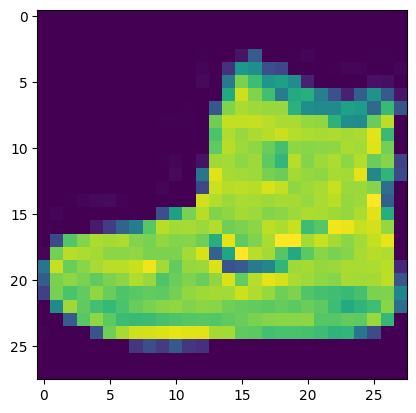

In [ ]:
plt.imshow(train_x[0])

In [ ]:
label_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Text(0.5, 1.0, 'Ankle boot')

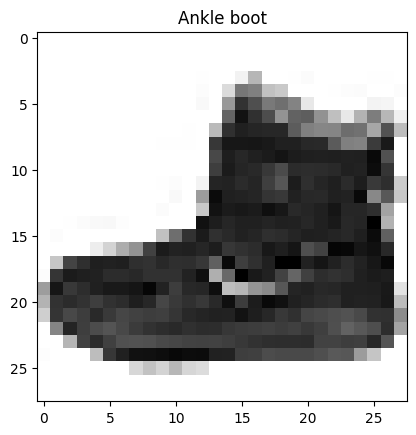

In [ ]:
plt.imshow(train_x[0],cmap=plt.cm.binary )#cmap='gray', cmap k through ap different views lay sakty hain picture ky.
plt.title(label_names[train_y[0]])

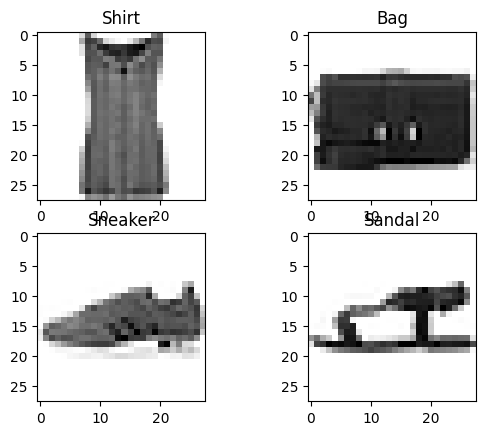

In [ ]:
import random
for i in range(4):
  ax = plt.subplot(2,2,i+1)
  rand_index = random.choice(range(len(train_x)))
  ax.imshow(train_x[rand_index],cmap=plt.cm.binary)
  ax.set_title(label_names[train_y[rand_index]])

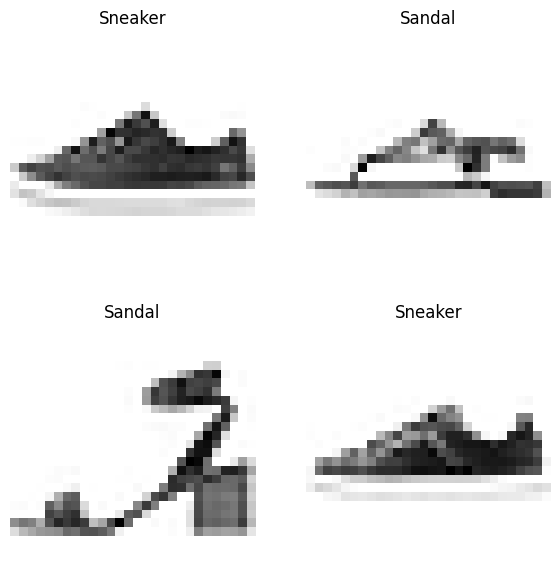

In [ ]:
plt.figure(figsize=(7,7))
for i in range(4):
  ax = plt.subplot(2,2,i+1)
  rand_index = random.choice(range(len(train_x)))
  plt.imshow(train_x[rand_index],cmap=plt.cm.binary)
  plt.title(label_names[train_y[rand_index]])
  ax.axis('off') # Change plt.axis(False) to plt.axis('off')

# **Building_MultiClass_model**

In [ ]:
tf.random.set_seed(42)
model_1 = Sequential()
model_1.add(Flatten(input_shape=(28,28)))
model_1.add(Dense(4,activation='relu'))
model_1.add(Dense(4,activation='relu'))
model_1.add(Dense(10,activation='softmax'))

model_1.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │           3,140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,210 (12.54 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import to_categorical
train_y_encoded = to_categorical(train_y, num_classes=10) # One-hot encode train_y
test_y_encoded = to_categorical(test_y, num_classes=10)  # One-hot encode test_y

In [ ]:
history_1 = model_1.fit(train_x,train_y_encoded,epochs=10,validation_data=(test_x,test_y_encoded))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.1073 - loss: 2.8962 - val_accuracy: 0.1048 - val_loss: 2.2924
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.1190 - loss: 2.2629 - val_accuracy: 0.1496 - val_loss: 2.1825
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1453 - loss: 2.2066 - val_accuracy: 0.1461 - val_loss: 2.1861
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1695 - loss: 2.1158 - val_accuracy: 0.1984 - val_loss: 2.0878
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1963 - loss: 1.8956 - val_accuracy: 0.2167 - val_loss: 1.8048
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2527 - loss: 1.7519 - val_accuracy: 0.2326 - val_loss: 1.8724
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2492 - loss: 1.7546 - val_accuracy: 0.2691 - val_loss: 1.7202
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2736 - loss: 1.6925 - 

If we use sparse_categorical_crossentropy, we don't need to onehot_encode our data.


In [ ]:
tf.random.set_seed(42)
model_2 = Sequential()
model_2.add(Flatten(input_shape=(28,28)))
model_2.add(Dense(4,activation='relu'))
model_2.add(Dense(4,activation='relu'))
model_2.add(Dense(10,activation='softmax'))

model_2.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

In [ ]:
history_2 = model_2.fit(train_x,train_y,epochs=10,validation_data=(test_x,test_y))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.1786 - loss: 2.4624 - val_accuracy: 0.2342 - val_loss: 1.9494
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2877 - loss: 1.7535 - val_accuracy: 0.3146 - val_loss: 1.4815
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3884 - loss: 1.4432 - val_accuracy: 0.3987 - val_loss: 1.3759
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4601 - loss: 1.3325 - val_accuracy: 0.4944 - val_loss: 1.2141
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5033 - loss: 1.1922 - val_accuracy: 0.5072 - val_loss: 1.1672
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5248 - loss: 1.1429 - val_accuracy: 0.5231 - val_loss: 1.1632
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5261 - loss: 1.1472 - val_accuracy: 0.5351 - val_loss: 1.0924
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5287 - loss: 1.1314 - 

# **Improving_Our_Model**

In [ ]:
train_x_normalised = train_x/255
test_x_normalised = test_x/255

In [ ]:
model_3 = Sequential()
model_3.add(Flatten(input_shape=(28,28)))
model_3.add(Dense(4,activation='relu'))
model_3.add(Dense(4,activation='relu'))
model_3.add(Dense(10,activation='softmax'))

model_3.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

In [ ]:
history_3 = model_3.fit(train_x_normalised,train_y,epochs=10,validation_data=(test_x_normalised,test_y))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3872 - loss: 1.5402 - val_accuracy: 0.7217 - val_loss: 0.8169
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7339 - loss: 0.7654 - val_accuracy: 0.7545 - val_loss: 0.7195
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7621 - loss: 0.6845 - val_accuracy: 0.7711 - val_loss: 0.6780
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7756 - loss: 0.6486 - val_accuracy: 0.7758 - val_loss: 0.6572
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7819 - loss: 0.6284 - val_accuracy: 0.7797 - val_loss: 0.6451
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7865 - loss: 0.6154 - val_accuracy: 0.7837 - val_loss: 0.6354
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7920 - loss: 0.6055 - val_accuracy: 0.7871 - val_loss: 0.6297
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7938 - loss: 0.5985 - 

<Axes: title={'center': 'normalised_model'}>

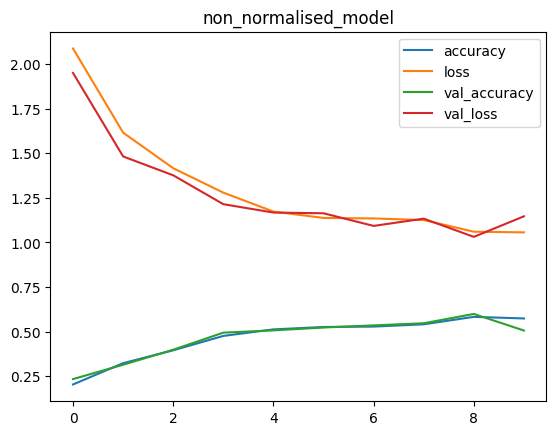

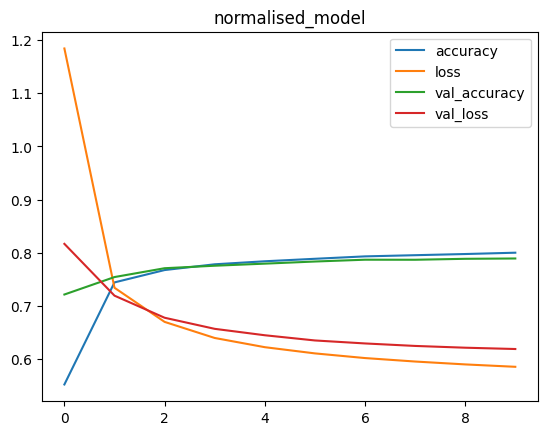

In [ ]:
import pandas as pd
pd.DataFrame(history_2.history).plot(title='non_normalised_model')
pd.DataFrame(history_3.history).plot(title='normalised_model')

In [ ]:
tf.random.set_seed(42)
model_4 = Sequential()
model_4.add(Flatten(input_shape=(28,28)))
model_4.add(Dense(4,activation='relu'))
model_4.add(Dense(4,activation='relu'))
model_4.add(Dense(10,activation='softmax'))

model_4.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lr_schedular = tf.keras.callbacks.LearningRateScheduler(lambda epoch:1e-3*10**(epoch/20))

In [ ]:
history = model_4.fit(train_x_normalised,train_y,epochs=40,validation_data=(test_x_normalised,test_y),callbacks=[lr_schedular])

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5088 - loss: 1.3232 - val_accuracy: 0.7739 - val_loss: 0.6463 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7839 - loss: 0.6099 - val_accuracy: 0.8000 - val_loss: 0.5865 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8016 - loss: 0.5628 - val_accuracy: 0.8083 - val_loss: 0.5622 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8091 - loss: 0.5421 - val_accuracy: 0.8130 - val_loss: 0.5467 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8139 - loss: 0.5294 - val_accuracy: 0.8144 - val_loss: 0.5373 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8164 - loss: 0.5206 - val_accuracy: 0.8177 - val_loss: 0.5299 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8178 - l

Text(0.5, 1.0, 'Learning Rate vs Loss')

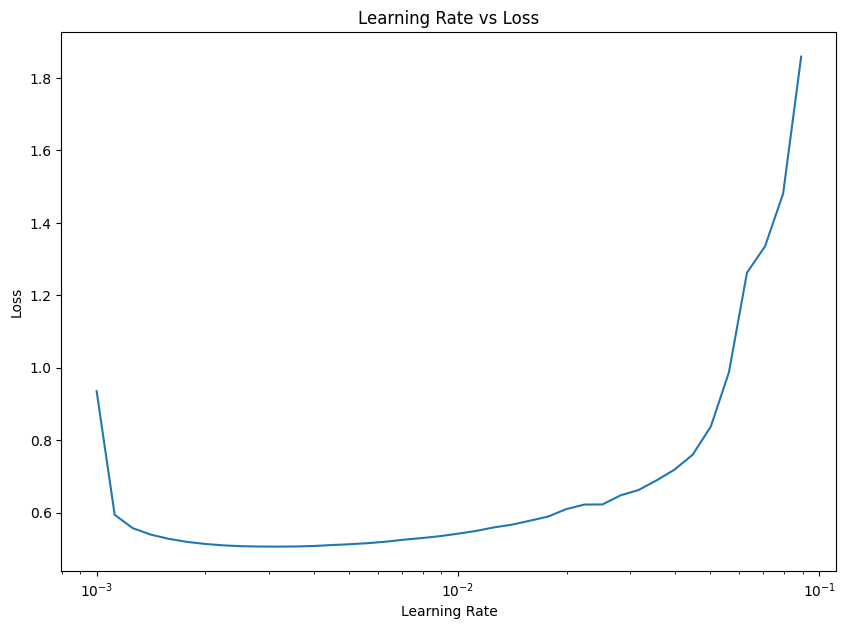

In [ ]:
lrs = 1e-3*(10**(tf.range(40)/20))
plt.figure(figsize=(10,7))
plt.semilogx(lrs,history.history['loss'])
plt.xlabel('Learning Rate')
plt.ylabel('Loss')
plt.title('Learning Rate vs Loss')

In [ ]:
tf.random.set_seed(42)
model_5 = Sequential()
model_5.add(Flatten(input_shape=(28,28)))
model_5.add(Dense(4,activation='relu'))
model_5.add(Dense(4,activation='relu'))
model_5.add(Dense(10,activation='softmax'))

model_5.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
#     filepath='/content/checkpoints/model_epoch_{epoch:02d}.keras',
#     save_freq=100,
#     save_best_only=False,  #if set to true then set save_freq to 300,400, 1 epoch(default value)
#     verbose=1
# )

In [ ]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/checkpoints/model_epoch_{epoch:02d}.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

In [ ]:
history_5 = model_5.fit(train_x_normalised,train_y,epochs=20,validation_data=(test_x_normalised,test_y), callbacks=[checkpoint_callback])

Epoch 1/20
1869/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3287 - loss: 1.7044
Epoch 1: val_accuracy improved from -inf to 0.57510, saving model to /content/checkpoints/model_epoch_01.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.3291 - loss: 1.7032 - val_accuracy: 0.5751 - val_loss: 0.9992
Epoch 2/20
1846/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6628 - loss: 0.8841
Epoch 2: val_accuracy improved from 0.57510 to 0.72710, saving model to /content/checkpoints/model_epoch_02.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6633 - loss: 0.8830 - val_accuracy: 0.7271 - val_loss: 0.7589
Epoch 3/20
1856/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7437 - loss: 0.7230
Epoch 3: val_accuracy improved from 0.72710 to 0.75440, saving model to /content/checkpoints/model_epoch_03.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7438 - loss: 0.7227 - val_accuracy: 0.7544 - val_loss: 0.7029
Epoch 4/20
1862/1875 ━━━━━━━━━━━━━━━━━━━

In [ ]:
history_5.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

<Axes: >

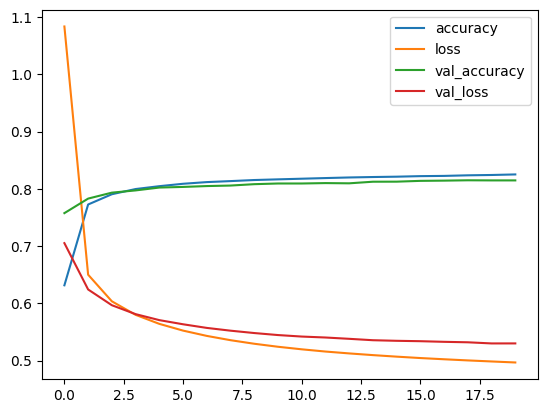

In [ ]:
pd.DataFrame(history_5.history).plot()

In [ ]:
y_probs = model_5.predict(test_x_normalised)
y_probs.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 10)

In [ ]:
y_preds = y_probs.argmax(axis=1)

In [ ]:
y_preds, test_y

(array([9, 2, 1, ..., 8, 1, 5]), array([9, 2, 1, ..., 8, 1, 5], dtype=uint8))

In [ ]:
unique_labels = np.unique(train_y)
class_images = {}
for label in unique_labels:
  class_index = np.where(train_y == label)[0][0]
  class_images[label] = train_x_normalised[class_index]

In [ ]:
def plot_random_image(model, image, true_label, class_names, class_images):
  random_index = random.randint(0, len(image))
  target_image, target_label = image[random_index], true_label[random_index]
  pred_probs = model.predict(target_image.reshape(1, 28, 28))
  preds = pred_probs.argmax(axis=1)
  pred_label = class_names[preds[0]]
  pred_image = class_images[preds[0]]

  plt.figure(figsize=(15, 7))
  plt.subplot(1, 2, 1)
  plt.imshow(target_image, cmap=plt.cm.binary)
  plt.title(f'Actual:{class_names[target_label]}', fontsize=15) # target_label is already an integer index

  if pred_label == class_names[target_label]:  # Compare pred_label with the string from class_names
    plt.subplot(1, 2, 2)
    plt.imshow(pred_image, cmap=plt.cm.binary)
    plt.title(f'Predicted:{pred_label}, True', fontsize=15)
  else:
    plt.subplot(1, 2, 2)
    plt.imshow(pred_image, cmap=plt.cm.binary)
    plt.title(f'Predicted:{pred_label}, False', fontsize=15)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


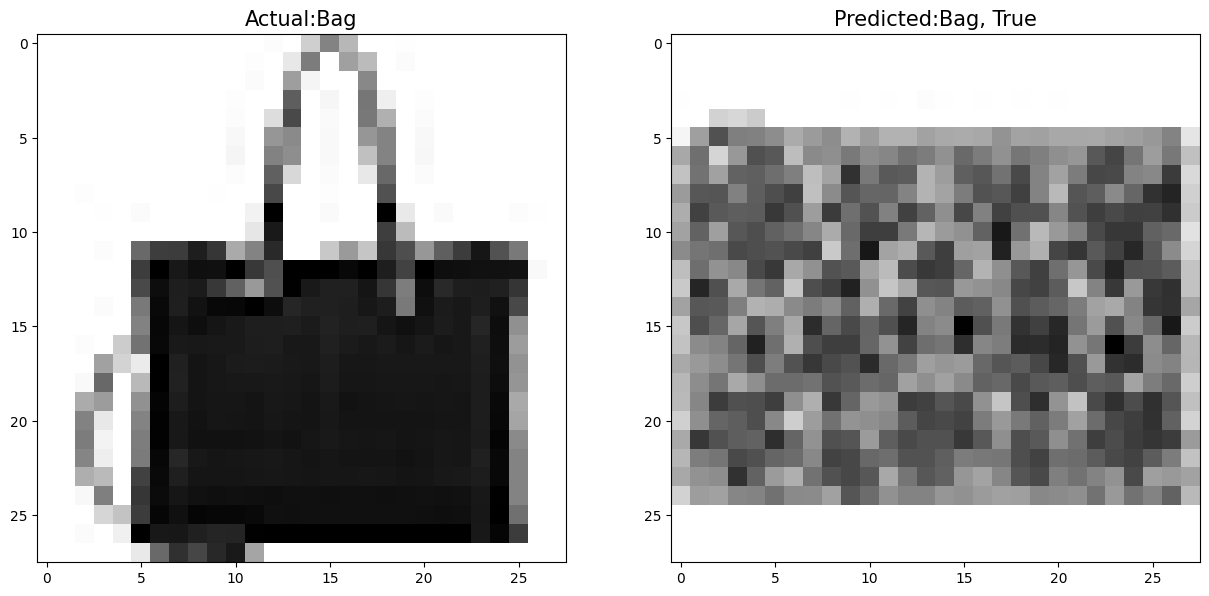

In [ ]:
plot_random_image(model_5,test_x_normalised,test_y,label_names, class_images)

# **Layers**

In [ ]:
model_5.layers

[<Flatten name=flatten_4, built=True>,
 <Dense name=dense_12, built=True>,
 <Dense name=dense_13, built=True>,
 <Dense name=dense_14, built=True>]

In [ ]:
model_5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 4)                   │           3,140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 4)                   │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 10)                  │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

In [ ]:
weights, biases = model_5.layers[1].get_weights()

In [ ]:
weights, weights.shape

(array([[ 0.23036674, -0.07517865,  0.23389937, -0.27623564],
        [ 0.23900662, -0.5154112 ,  0.9525055 , -0.9418174 ],
        [ 0.85473925, -1.1252698 , -0.00191338, -0.9230652 ],
        ...,
        [ 0.313762  , -0.09256426,  0.26754126, -0.8160518 ],
        [-0.1816164 , -0.1232707 ,  0.39819628, -0.01209692],
        [ 0.41339576, -0.41891927, -0.03154009, -0.7592979 ]],
       dtype=float32),
 (784, 4))

In [ ]:
biases, biases.shape

(array([0.26216397, 1.404735  , 0.49644977, 0.89435846], dtype=float32), (4,))

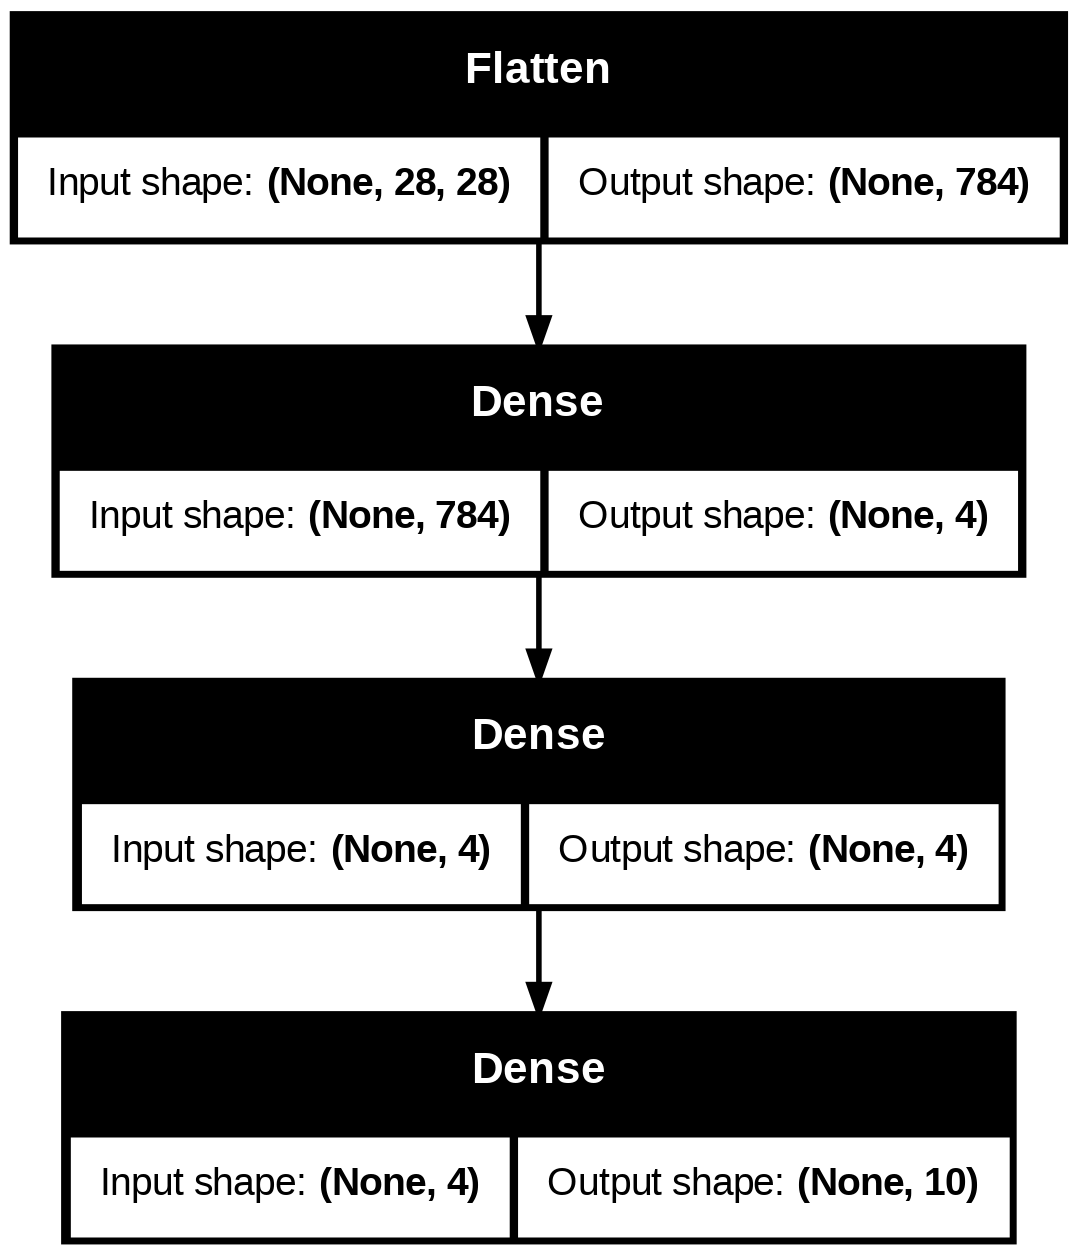

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model_5,show_shapes=True)

# **Save_Load_Model**

In [ ]:
import joblib

In [ ]:
joblib.dump(model_3,'fashion_mnist_model_5.joblib')

NameError: name 'model_3' is not defined